# Lab 6.01 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [2]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables.


<Axes: xlabel='Hwt', ylabel='Bwt'>

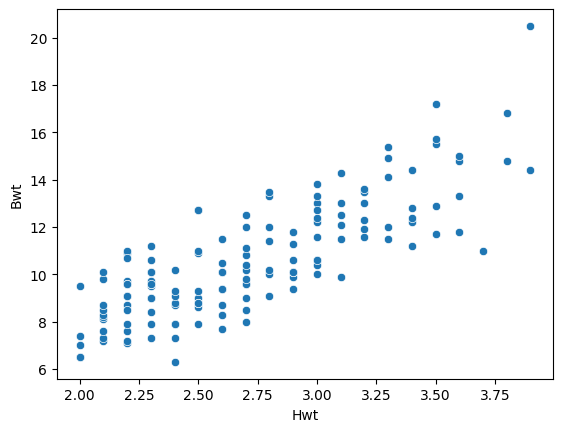

In [7]:
sns.scatterplot(data=cats, x='Hwt', y='Bwt')

3. Calculate and draw the regression line.


In [10]:
a, b = np.polyfit(cats['Hwt'], cats['Bwt'], deg=1)
a, b

(np.float64(4.031757486783179), np.float64(-0.3510783771969617))

4. Calculate the correlation coefficient and the coefficient of determination.

In [11]:
cor = np.corrcoef(cats['Hwt'], cats['Bwt'])[0][1]
cod = cor ** 2
cor, cod

(np.float64(0.804134787315513), np.float64(0.6466327561709654))

5. Interpret the results from the previous steps.

The cor being close to 1 means the points in the scatterplot are close to a straight line. There is an increasing and strong linear relation.  
The cod being 0.64 

### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [12]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables for each gender.


<Axes: xlabel='Hwt', ylabel='Bwt'>

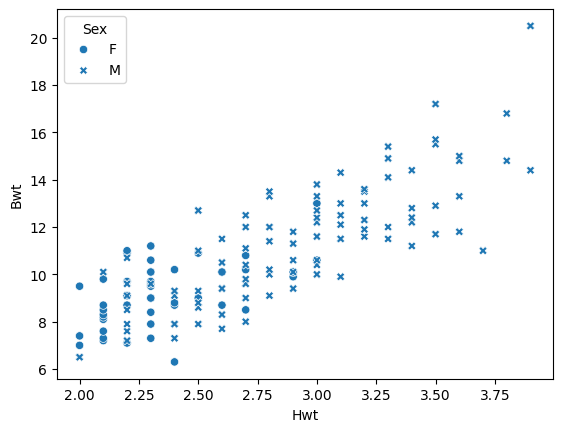

In [13]:
sns.scatterplot(data=cats, x=cats['Hwt'], y=cats['Bwt'], style=cats['Sex'])

3. Calculate and draw the regression line.


In [19]:
a, b = np.polyfit(cats[cats['Sex'] == 'M']['Hwt'], cats[cats['Sex'] == 'M']['Bwt'], deg=1)
a2, b2 = np.polyfit(cats[cats['Sex'] == 'F']['Hwt'], cats[cats['Sex'] == 'F']['Bwt'], deg=1)

a, b, a2, b2

(np.float64(4.309818875119161),
 np.float64(-1.176825253309489),
 np.float64(2.6364140480591503),
 np.float64(2.981312384473199))

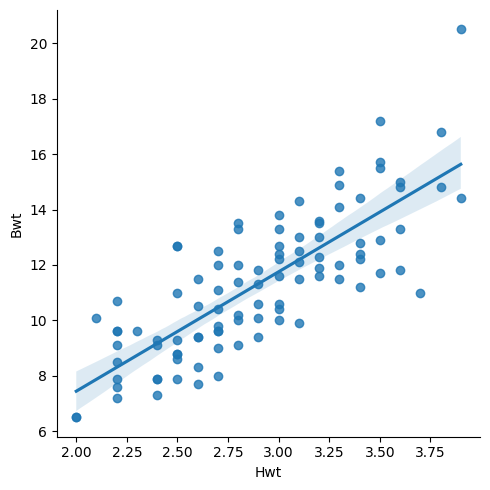

In [23]:
katers = cats[cats['Sex'] == 'M']
sns.lmplot(data=katers, x='Hwt', y='Bwt')

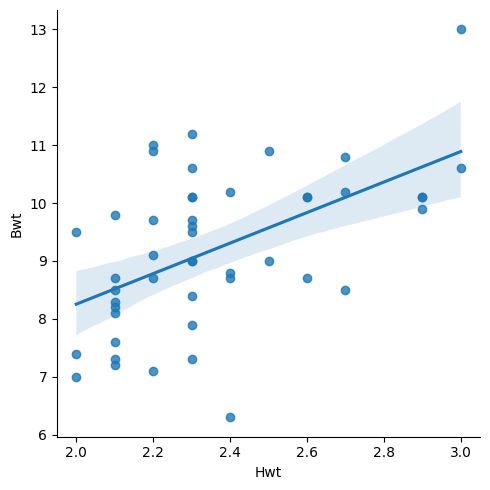

In [24]:
poezen = cats[cats['Sex'] == 'F']
sns.lmplot(data=poezen, x='Hwt', y='Bwt')

4. Calculate the correlation coefficient and the coefficient of determination.


In [26]:
cork = np.corrcoef(katers['Hwt'], katers['Bwt'])[0][1]
corp = np.corrcoef(poezen['Hwt'], poezen['Bwt'])[0][1]

codk = cork ** 2
codp = corp ** 2

cork, corp, codk, codp

(np.float64(0.7930443171812304),
 np.float64(0.5320496665060397),
 np.float64(0.628919289013444),
 np.float64(0.28307684762918806))

5. Interpret the results from the previous steps.

The male cats show an increasing and strong linear relationship between their heartweight and their bodyweight.  
The female cats show an increasing linear relationship between their heartweight and their bodyweight. But not as strong as the males.

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
